# 4.8

### 슬라이드 12-13

* 174-175p 퍼셉트론 구현 #1 (순수 파이썬 사용)

In [ ]:
epsilon = 0.0000001

def perceptron(x1, x2) :
    w1, w2, b = 1.0, 1.0, -1.5
    sum = x1*w1+x2*w2+b
    if sum > epsilon :  # 부동소수점 오차를 방지하기 위하여
        return 1
    else :
        return 0

In [ ]:
print(perceptron(0, 0))
print(perceptron(1, 0))
print(perceptron(0, 1))
print(perceptron(1, 1))

0
0
0
1


* 176p 퍼셉트론 구현 #2 (넘파이 사용)

In [ ]:
import numpy as np
epsilon = 0.0000001

def perceptron(x1, x2) :
    X = np.array([x1, x2])
    W = np.array([1.0, 1.0])
    B = -1.5
    sum = np.dot(W, X)+B
    if sum > epsilon :
        return 1
    else :
        return 0

print(perceptron(0, 0))
print(perceptron(1, 0))
print(perceptron(0, 1))
print(perceptron(1, 1))

0
0
0
1


### 슬라이드 18-24

* 179-181p 퍼셉트론 학습 알고리즘 구현하기

In [ ]:
import numpy as np

epsilon = 0.0000001 # 부동소수점 오차 방지

def step_func(t) :  # 퍼셉트론의 활성화 함수
    if t > epsilon: return 1
    else : return 0

X = np.array([          # 훈련 데이터 세트
            [0, 0, 1],  # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
            [0, 1, 1],  # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
            [1, 0, 1],  # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
            [1, 1, 1]   # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
])

y = np.array([0, 0, 0, 1])  # 정답을 저장하는 넘파이 행렬
W = np.zeros(len(X[0]))     # 가중치를 저장하는 넘파이 행렬

def perceptron_fit(X, Y, epochs=10) :    # 퍼셉트론 학습 알고리즘 구현
    global W
    eta = 0.2   # 학습률

    for t in range(epochs) :
        print("epoch=", t, "======================")
        for i in range(len(X)) :
            predict = step_func(np.dot(X[i], W))
            error = Y[i] - predict  # 오차 계산
            W += eta * error * X[i] # 가중치 업데이트
            print("현재 처리 입력=",X[i],"정답=",Y[i],"출력=",predict,"변경된 가중치=", W)
            print("===============================")

def perceptron_predict(X, Y):   # 예측
    global W
    for x in X:
        print(x[0], x[1], "->", step_func(np.dot(x, W)))

perceptron_fit(X, y, 6)
perceptron_predict(X, y)

epoch= 0 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [0. 0. 0.]
현재 처리 입력= [0 1 1] 정답= 0 출력= 0 변경된 가중치= [0. 0. 0.]
현재 처리 입력= [1 0 1] 정답= 0 출력= 0 변경된 가중치= [0. 0. 0.]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [0.2 0.2 0.2]
epoch= 1 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 1 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [0 1 1] 정답= 0 출력= 1 변경된 가중치= [ 0.2  0.  -0.2]
현재 처리 입력= [1 0 1] 정답= 0 출력= 0 변경된 가중치= [ 0.2  0.  -0.2]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [0.4 0.2 0. ]
epoch= 2 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [0.4 0.2 0. ]
현재 처리 입력= [0 1 1] 정답= 0 출력= 1 변경된 가중치= [ 0.4  0.  -0.2]
현재 처리 입력= [1 0 1] 정답= 0 출력= 1 변경된 가중치= [ 0.2  0.  -0.4]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [ 0.4  0.2 -0.2]
epoch= 3 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [ 0.4  0.2 -0.2]
현재 처리 입력= [0 1 1] 정답= 0 출력= 0 변경된 가중치= [ 0.4  0.2 -0.2]
현재 처리 입력= [1 0 1] 정답= 0 출력= 1 변경된 가중치= [ 0.2  0.2 -0.4]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [ 0.4  0.4 -0.2]
epoch=

In [ ]:
# sklearn으로 퍼셉트론 실습하기
from sklearn.linear_model import Perceptron

# 논리적 AND 연산 샘플과 정답이다.
X = [[0, 0], [0, 1], [1, 0], [1, 1]]  # 항상 2차원 배열이어야 한다.
y = [0, 0, 0, 1]

In [ ]:
# 퍼셉트론을 생성한다. tol은 종료 조건이다. random_state는 난수의 시드이다
clf = Perceptron(tol=1e-3, random_state = 0)

# 학습을 수행한다.
clf.fit(X, y)

print(clf.predict(X))

[0 0 0 1]


### Mini Project : 퍼셉트론으로 분류

In [ ]:
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. 데이터 준비
X_raw = np.array([[170, 80], [175, 76], [180, 70], [160, 55], [163, 43], [165, 48]])
y = np.array([1, 1, 1, 0, 0, 0])  # 1: 남성, 0: 여성

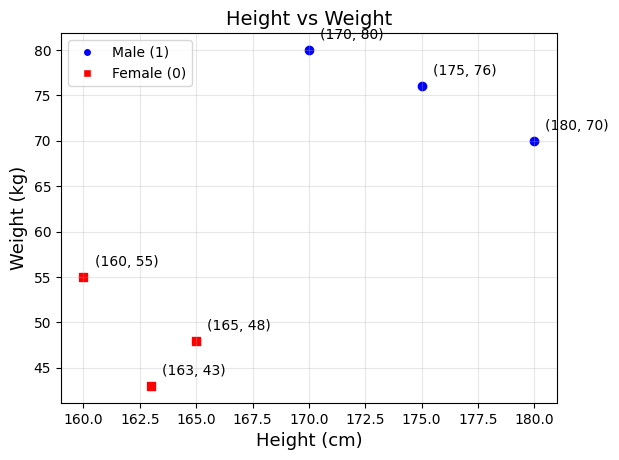

In [ ]:
# 2. 데이터 시각화
for i in range(len(X_raw)):
    if y[i] == 1:   # 산점도 생성
        plt.scatter(X_raw[i, 0], X_raw[i, 1], c='blue', marker='o')
    else:
        plt.scatter(X_raw[i, 0], X_raw[i, 1], c='red', marker='s')

    plt.annotate(f'({X_raw[i, 0]}, {X_raw[i, 1]})', (X_raw[i, 0], X_raw[i, 1]),
                 textcoords="offset points", xytext=(8, 8))

legend = [  # 범례
    Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', label='Male (1)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='red', label='Female (0)')
]
plt.legend(handles=legend)
plt.xlabel('Height (cm)', fontsize=13)
plt.ylabel('Weight (kg)', fontsize=13)
plt.title('Height vs Weight', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 3. 정규화

mean = X_raw.mean(axis=0)   # 평균
std = X_raw.std(axis=0)     # 표준편차
X_scaled = (X_raw - mean) / std    # 정규화

print(X_raw.mean(axis=0))
print(X_raw.std(axis=0))

[72.875 70.375]
[19.04230488 17.24048651]


In [ ]:
# 4. 학습

clf = Perceptron() # 모델 생성
clf.fit(X_scaled, y) # 학습

# 결과 확인 (출력)
print("가중치 (w):", clf.coef_)
print("바이어스 (b):", clf.intercept_)
print("훈련 정확도:", clf.score(X_scaled, y))

가중치 (w): [[0.88573541 0.99410024]]
바이어스 (b): [1.]
훈련 정확도: 1.0


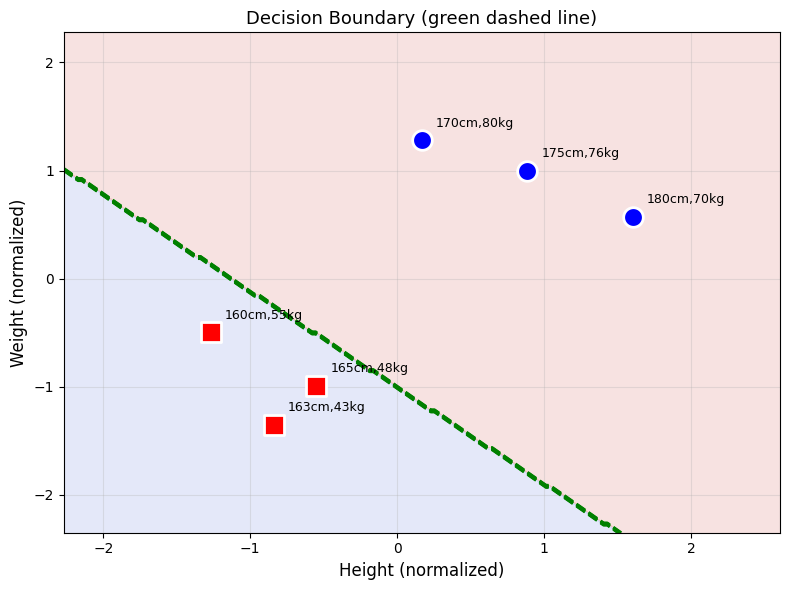

In [ ]:
# 5. 결정경계 시각화

fig, ax = plt.subplots(figsize=(8, 6))
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.15, cmap='coolwarm')
ax.contour(xx, yy, Z, colors='green', linewidths=2, linestyles='--')

for i in range(len(X_scaled)):
   color = 'blue' if y[i] == 1 else 'red'
   marker = 'o' if y[i] == 1 else 's'
   ax.scatter(X_scaled[i, 0], X_scaled[i, 1], c=color, s=200, marker=marker,
             zorder=5, edgecolors='white', linewidth=2)
   ax.annotate(f'{X_raw[i][0]}cm,{X_raw[i][1]}kg',
               (X_scaled[i, 0], X_scaled[i, 1]),
               textcoords="offset points", xytext=(10, 10), fontsize=9)

ax.set_xlabel('Height (normalized)', fontsize=12)
ax.set_ylabel('Weight (normalized)', fontsize=12)
ax.set_title('Decision Boundary (green dashed line)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 6. 예측

new_data = np.array([[157, 55]])    # 새로운 데이터
new_data_scaled = (new_data - mean) / std   # 정규화

pred = clf.predict(new_data_scaled)

# 결과 출력
if pred[0] == 1:
    print("예측 결과: 남성")
else:
    print("예측 결과: 여성")

print("입력 데이터:", new_data)
print("정규화된 데이터:", new_data_scaled)

예측 결과: 여성
입력 데이터: [[157  55]]
정규화된 데이터: [[-1.69965444 -0.49705012]]


### 연습문제 1

In [ ]:
# OR 연산을 퍼셉트론으로

import numpy as np

epsilon = 0.0000001 # 부동소수점 오차 방지

def step_func(t) :  # 퍼셉트론의 활성화 함수
    if t > epsilon: return 1
    else : return 0

X = np.array([          # 훈련 데이터 세트
            [0, 0, 1],  # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
            [0, 1, 1],  # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
            [1, 0, 1],  # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
            [1, 1, 1]   # 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
])

y = np.array([0, 1, 1, 1])  # 정답을 저장하는 넘파이 행렬   ### 이 부분만 변경
W_or = np.zeros(len(X[0]))     # 가중치를 저장하는 넘파이 행렬

def perceptron_fit(X, Y, epochs=10) :    # 퍼셉트론 학습 알고리즘 구현
    global W_or
    eta = 0.2   # 학습률

    for t in range(epochs) :
        print("epoch=", t, "======================")
        for i in range(len(X)) :
            predict = step_func(np.dot(X[i], W_or))
            error = Y[i] - predict  # 오차 계산
            W_or += eta * error * X[i] # 가중치 업데이트
            print("현재 처리 입력=",X[i],"정답=",Y[i],"출력=",predict,"변경된 가중치=", W_or)
            print("===============================")

def perceptron_predict(X, Y):   # 예측
    global W_or
    for x in X:
        print(x[0], x[1], "->", step_func(np.dot(x, W_or)))

perceptron_fit(X, y, 6)
perceptron_predict(X, y)

epoch= 0 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [0. 0. 0.]
현재 처리 입력= [0 1 1] 정답= 1 출력= 0 변경된 가중치= [0.  0.2 0.2]
현재 처리 입력= [1 0 1] 정답= 1 출력= 1 변경된 가중치= [0.  0.2 0.2]
현재 처리 입력= [1 1 1] 정답= 1 출력= 1 변경된 가중치= [0.  0.2 0.2]
epoch= 1 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 1 변경된 가중치= [0.  0.2 0. ]
현재 처리 입력= [0 1 1] 정답= 1 출력= 1 변경된 가중치= [0.  0.2 0. ]
현재 처리 입력= [1 0 1] 정답= 1 출력= 0 변경된 가중치= [0.2 0.2 0.2]
현재 처리 입력= [1 1 1] 정답= 1 출력= 1 변경된 가중치= [0.2 0.2 0.2]
epoch= 2 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 1 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [0 1 1] 정답= 1 출력= 1 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [1 0 1] 정답= 1 출력= 1 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [1 1 1] 정답= 1 출력= 1 변경된 가중치= [0.2 0.2 0. ]
epoch= 3 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [0 1 1] 정답= 1 출력= 1 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [1 0 1] 정답= 1 출력= 1 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [1 1 1] 정답= 1 출력= 1 변경된 가중치= [0.2 0.2 0. ]
epoch= 4 ==================

OR 연산이 AND보다 더 빠르게 학습된다.
OR 연산은 3번째 에포크에서 가중치가 수렴하지만, AND 연산은 4번째 에포크까지 가중치 변화가 나타남을 알 수 있다.
AND는 두 입력이 모두 1일 때만 1을 출력해야 하기 때문에 가중치가 더 정교하게 조정되지만, OR는 하나만 1이어도 되므로 정답에 도달하는 학습 횟수가 상대적으로 짧다.

AND와 OR는 정답을 나누는 결정 경계가 다르므로 이를 구성하는 가중치와 바이어스 값 또한 서로 다른 수치로 나타난다. AND는 음수 바이어스를 통해 두 입력이 모두 1인 엄격한 조건을 학습하는 반면, OR는 바이어스를 0으로 만들어 하나의 입력만으로도 결과를 내도록 가중치가 형성된다.

### 연습문제 2

In [ ]:
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. 데이터 준비 (국어, 수학)
X_raw = np.array([
    [92, 88], [90, 85], [95, 91], [88, 84],   # 장학금 (1)
    [55, 60], [50, 45], [65, 58], [48, 52]    # 미지급 (0)
])

y = np.array([1, 1, 1, 1, 0, 0, 0, 0])

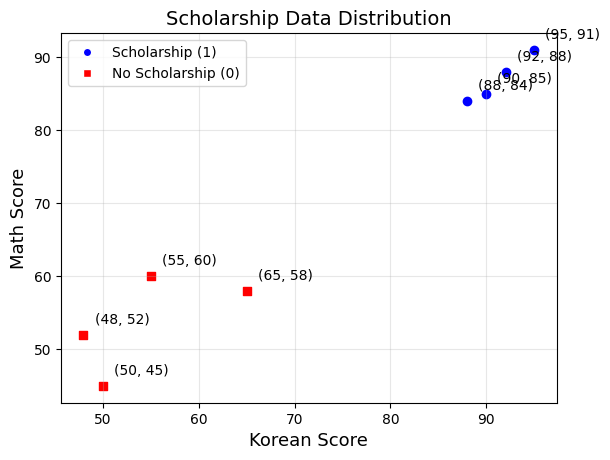

In [ ]:
# 2. 시각화
for i in range(len(X_raw)):
    if y[i] == 1:
        plt.scatter(X_raw[i, 0], X_raw[i, 1], c='blue', marker='o')
    else:
        plt.scatter(X_raw[i, 0], X_raw[i, 1], c='red', marker='s')

    plt.annotate(f'({X_raw[i, 0]}, {X_raw[i, 1]})',
                 (X_raw[i, 0], X_raw[i, 1]),
                 textcoords="offset points", xytext=(8, 8))

legend = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', label='Scholarship (1)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='red', label='No Scholarship (0)')
]

plt.legend(handles=legend)
plt.xlabel('Korean Score', fontsize=13)
plt.ylabel('Math Score', fontsize=13)
plt.title('Scholarship Data Distribution', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 3. 정규화
mean = X_raw.mean(axis=0)
std = X_raw.std(axis=0)

X_scaled = (X_raw - mean) / std

print(mean)
print(std)

[72.875 70.375]
[19.04230488 17.24048651]


In [ ]:
# 4. 학습
clf = Perceptron()
clf.fit(X_scaled, y)

print("가중치 (w):", clf.coef_)
print("바이어스 (b):", clf.intercept_)
print("훈련 정확도:", clf.score(X_scaled, y))

가중치 (w): [[1.30630195 1.06580519]]
바이어스 (b): [-1.]
훈련 정확도: 1.0


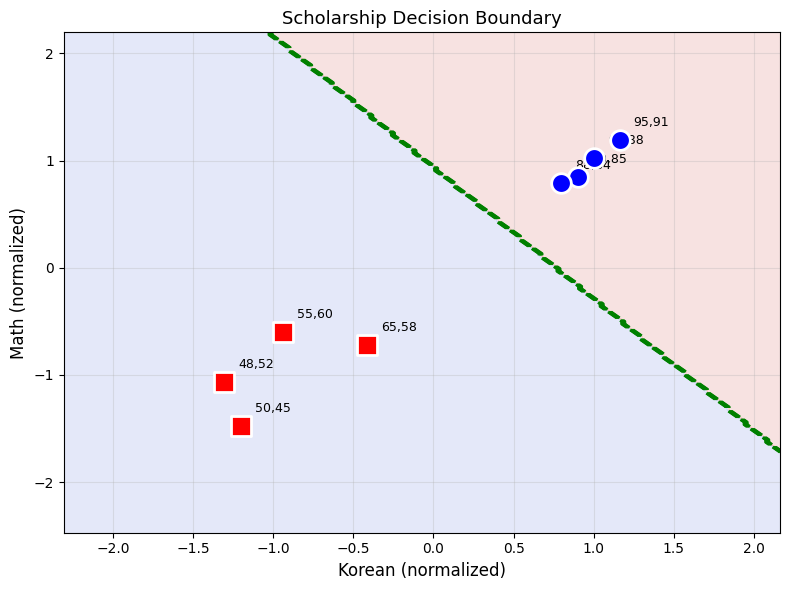

In [ ]:
# 5. 결정경계 시각화
fig, ax = plt.subplots(figsize=(8, 6))
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.15, cmap='coolwarm')
ax.contour(xx, yy, Z, colors='green', linewidths=2, linestyles='--')

for i in range(len(X_scaled)):
   color = 'blue' if y[i] == 1 else 'red'
   marker = 'o' if y[i] == 1 else 's'
   ax.scatter(X_scaled[i, 0], X_scaled[i, 1], c=color, s=200, marker=marker,
             zorder=5, edgecolors='white', linewidth=2)
   ax.annotate(f'{X_raw[i][0]},{X_raw[i][1]}',
               (X_scaled[i, 0], X_scaled[i, 1]),
               textcoords="offset points", xytext=(10, 10), fontsize=9)

ax.set_xlabel('Korean (normalized)', fontsize=12)
ax.set_ylabel('Math (normalized)', fontsize=12)
ax.set_title('Scholarship Decision Boundary', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 6. 예측
new_data = np.array([[78, 82]])

new_data_scaled = (new_data - mean) / std

pred = clf.predict(new_data_scaled)

if pred[0] == 1:
    print("예측 결과: 장학금 대상")
else:
    print("예측 결과: 미대상")

print("입력:", new_data)
print("정규화:", new_data_scaled)

예측 결과: 장학금 대상
입력: [[78 82]]
정규화: [[0.26913759 0.67428492]]


### 연습문제 3

In [ ]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

# 데이터 로드 및 슬라이싱
iris = datasets.load_iris()

X = iris.data[:, :2]
y = iris.target

In [ ]:
from sklearn.model_selection import train_test_split

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

In [ ]:
# 정규화
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 모델 학습
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
from sklearn import metrics

# 성능 평가
y_pred = knn.predict(X_test_scaled)
score = metrics.accuracy_score(y_test, y_pred)

print("정확도:", score)

정확도: 0.8333333333333334


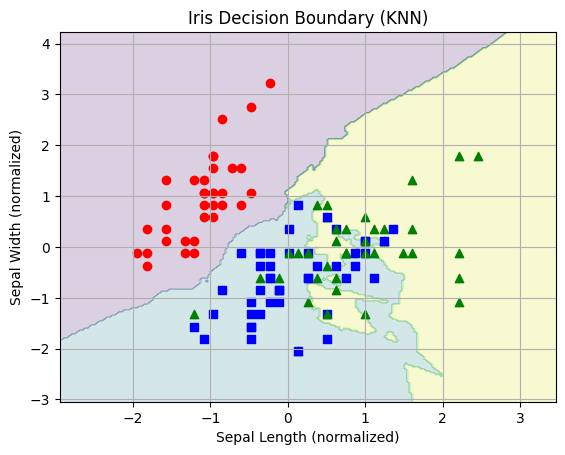

In [ ]:
# 결정경계 시각화
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2)

for i in range(len(X_train_scaled)):
    if y_train[i] == 0:
        plt.scatter(X_train_scaled[i, 0], X_train_scaled[i, 1], c='red', marker='o')
    elif y_train[i] == 1:
        plt.scatter(X_train_scaled[i, 0], X_train_scaled[i, 1], c='blue', marker='s')
    else:
        plt.scatter(X_train_scaled[i, 0], X_train_scaled[i, 1], c='green', marker='^')

plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title('Iris Decision Boundary (KNN)')
plt.grid(True)
plt.show()

In [ ]:
# 새로운 데이터 예측
classes = {0:'setosa', 1:'versicolor', 2:'virginica'}

x_new = np.array([[6, 2],
                  [5, 3]])

x_new_scaled = (x_new - mean) / std

y_predict = knn.predict(x_new_scaled)

print(classes[y_predict[0]])
print(classes[y_predict[1]])

versicolor
setosa
